In [2]:
%pip install google-cloud-bigquery pandas matplotlib seaborn pyarrow

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from google.cloud import bigquery

# Initialize the BigQuery Client
# TODO: Put your actual GCP project ID between the quotes below
client = bigquery.Client(project="sctp-team2-project2-elt")

print("BigQuery client successfully initialized!")

/home/angjennfang/miniconda3/envs/pds/lib/python3.10/site-packages/google/api_core/_python_version_support.py:255: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


BigQuery client successfully initialized!


In [4]:
%pip install db-dtypes

Note: you may need to restart the kernel to use updated packages.


Fetching revenue data from BigQuery...


/home/angjennfang/miniconda3/envs/pds/lib/python3.10/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


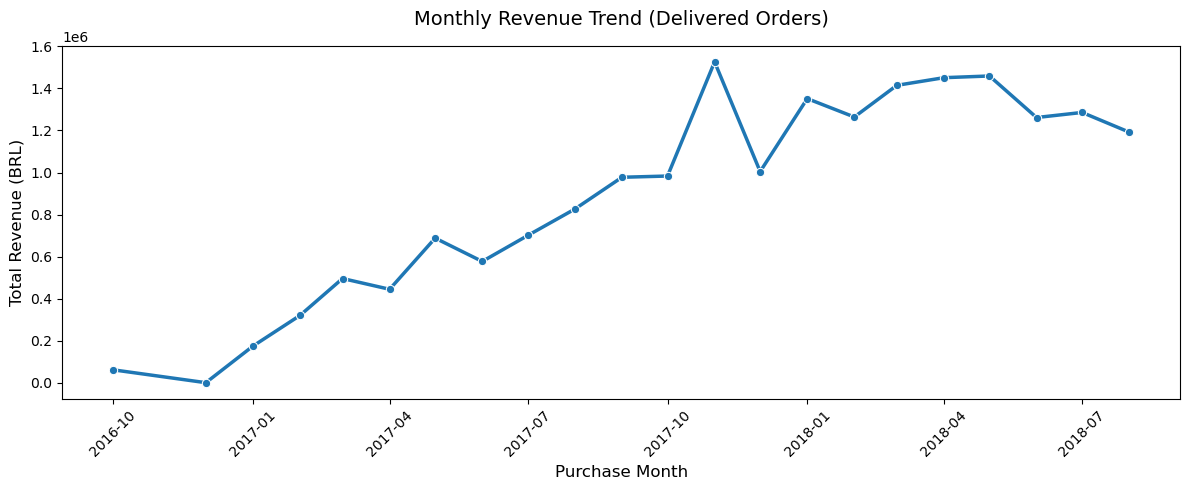

Fetching payment data from BigQuery...


/home/angjennfang/miniconda3/envs/pds/lib/python3.10/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


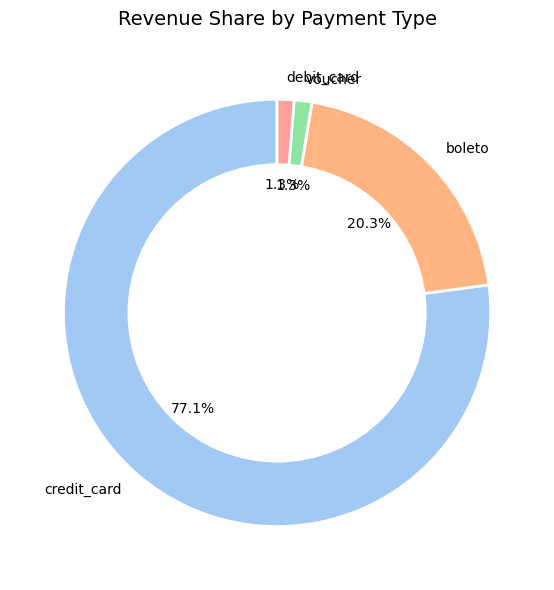

In [61]:
# =====================================================================
# CHART 1: Monthly Revenue Trend
# =====================================================================

# Query to aggregate payment value by month
revenue_query = """
SELECT 
    DATE_TRUNC(order_purchase_timestamp, MONTH) as order_month,
    SUM(payment_value) as total_revenue,
    COUNT(DISTINCT id) as total_orders
FROM `olist_gold_mart_prod.fact_orders`
WHERE order_status = 'delivered'  # Focusing on completed sales
GROUP BY order_month
ORDER BY order_month;
"""

print("Fetching revenue data from BigQuery...")
df_revenue = client.query(revenue_query).to_dataframe()

# Plotting the Line Chart
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=df_revenue,
    x="order_month",
    y="total_revenue",
    marker="o",
    color="#1f77b4",
    linewidth=2.5,
)
plt.title("Monthly Revenue Trend (Delivered Orders)", fontsize=14, pad=15)
plt.xlabel("Purchase Month", fontsize=12)
plt.ylabel("Total Revenue (BRL)", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# =====================================================================
# CHART 2: Payment Method Breakdown
# =====================================================================

# Query to find preferred payment options
payment_query = """
SELECT 
    payment_type,
    SUM(payment_value) as total_value,
    COUNT(DISTINCT id) as order_count
FROM `olist_gold_mart_prod.fact_orders`
GROUP BY payment_type
ORDER BY total_value DESC;
"""

print("Fetching payment data from BigQuery...")
df_payment = client.query(payment_query).to_dataframe()

# Cleaning up any undefined categories if they exist
df_payment = df_payment[df_payment["payment_type"] != "not_defined"]

# Plotting the Donut Chart
plt.figure(figsize=(6, 6))
colors = sns.color_palette("pastel")[0 : len(df_payment)]

plt.pie(
    df_payment["total_value"],
    labels=df_payment["payment_type"],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 2, "antialiased": True},
)

# Turn it into a donut chart
centre_circle = plt.Circle((0, 0), 0.70, fc="white")
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Revenue Share by Payment Type", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

Fetching comprehensive financial and cohort data from BigQuery...


/home/angjennfang/miniconda3/envs/pds/lib/python3.10/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


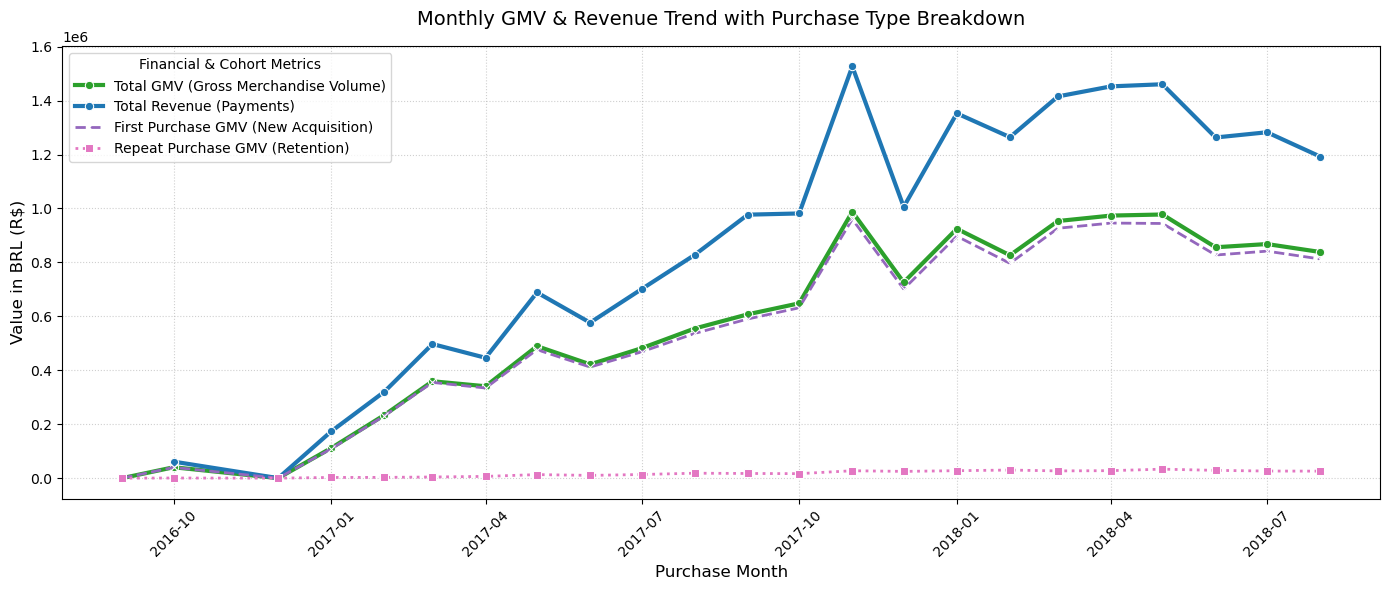

Fetching payment-level GMV data...


/home/angjennfang/miniconda3/envs/pds/lib/python3.10/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


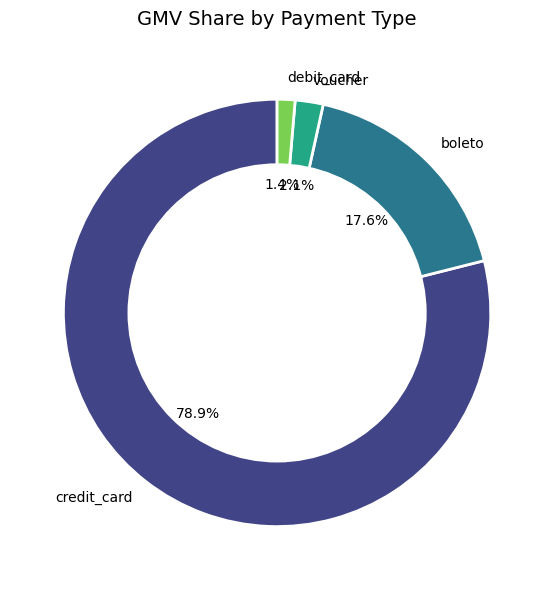

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =====================================================================
# 1. MONTHLY REVENUE, TOTAL GMV, & COHORT BREAKDOWN TREND
# =====================================================================

# Enhanced query to calculate order sequence per unique customer
revenue_query = """
WITH order_rank AS (
  SELECT
    id AS order_id,
    ANY_VALUE(customer_id) AS customer_id,
    ANY_VALUE(order_purchase_timestamp) AS purchase_ts
  FROM `olist_gold_mart_prod.fact_orders`
  WHERE order_status = 'delivered'
  GROUP BY id
),
customer_rank AS (
  SELECT
    order_id,
    purchase_ts,
    ROW_NUMBER() OVER (PARTITION BY c.customer_unique_id ORDER BY purchase_ts) AS order_seq
  FROM order_rank r
  LEFT JOIN `olist_gold_mart_prod.dim_customers` c ON r.customer_id = c.id
)
SELECT
  DATE_TRUNC(f.order_purchase_timestamp, MONTH) as order_month,
  SUM(f.price) as total_gmv,
  SUM(f.payment_value) as total_revenue,
  SUM(CASE WHEN cr.order_seq = 1 THEN f.price ELSE 0 END) as gmv_first_purchase,
  SUM(CASE WHEN cr.order_seq > 1 THEN f.price ELSE 0 END) as gmv_repeat_purchase
FROM `olist_gold_mart_prod.fact_orders` f
LEFT JOIN customer_rank cr ON f.id = cr.order_id
WHERE f.order_status = 'delivered'
GROUP BY order_month
ORDER BY order_month;
"""

print("Fetching comprehensive financial and cohort data from BigQuery...")
df_revenue = client.query(revenue_query).to_dataframe()

# Initialize the plot layout
plt.figure(figsize=(14, 6))

# Plot Core Metrics (Solid Lines)
sns.lineplot(
    data=df_revenue, 
    x="order_month", 
    y="total_gmv", 
    label="Total GMV (Gross Merchandise Volume)", 
    color="#2ca02c", 
    linewidth=3, 
    marker="o"
)
sns.lineplot(
    data=df_revenue, 
    x="order_month", 
    y="total_revenue", 
    label="Total Revenue (Payments)", 
    color="#1f77b4", 
    linewidth=3, 
    marker="o"
)

# Plot Cohort Breakdowns (Dotted Lines as requested)
sns.lineplot(
    data=df_revenue, 
    x="order_month", 
    y="gmv_first_purchase", 
    label="First Purchase GMV (New Acquisition)", 
    color="#9467bd",          # Executive Purple
    linewidth=2, 
    linestyle="--",           # Dashed to represent a sub-component
    marker="x"
)
sns.lineplot(
    data=df_revenue, 
    x="order_month", 
    y="gmv_repeat_purchase", 
    label="Repeat Purchase GMV (Retention)", 
    color="#e377c2",          # Distinct pink highlight
    linewidth=2, 
    linestyle=":",            # Clean dotted styling
    marker="s"
)

# Chart styling and labels
plt.title("Monthly GMV & Revenue Trend with Purchase Type Breakdown", fontsize=14, pad=15)
plt.xlabel("Purchase Month", fontsize=12)
plt.ylabel("Value in BRL (R$)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(title="Financial & Cohort Metrics", loc="upper left")
plt.tight_layout()
plt.show()


# =====================================================================
# 2. PAYMENT METHOD BREAKDOWN (BASED ON GMV)
# =====================================================================
payment_query = """
SELECT 
    payment_type,
    SUM(price) as total_gmv,
    COUNT(DISTINCT id) as order_count
FROM `olist_gold_mart_prod.fact_orders`
GROUP BY payment_type
ORDER BY total_gmv DESC;
"""

print("Fetching payment-level GMV data...")
df_payment = client.query(payment_query).to_dataframe()
df_payment = df_payment[df_payment["payment_type"] != "not_defined"]

plt.figure(figsize=(6, 6))
colors = sns.color_palette("viridis", len(df_payment))

plt.pie(
    df_payment["total_gmv"],
    labels=df_payment["payment_type"],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 2, "antialiased": True},
)

centre_circle = plt.Circle((0, 0), 0.70, fc="white")
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("GMV Share by Payment Type", fontsize=14, pad=15)
plt.tight_layout()
plt.show()


⏳ Querying BigQuery database (calculating unique customer counts)...


/home/angjennfang/miniconda3/envs/elt/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


✅ Data successfully retrieved from BigQuery!

--- Summary Table Results ---
      customer_type  total_customers  percentage
First-Time Customer            90557   96.999722
    Repeat Customer             2801    3.000278
-----------------------------



/tmp/ipykernel_126120/2607153345.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['customer_type'], fontweight='bold', fontsize=11)


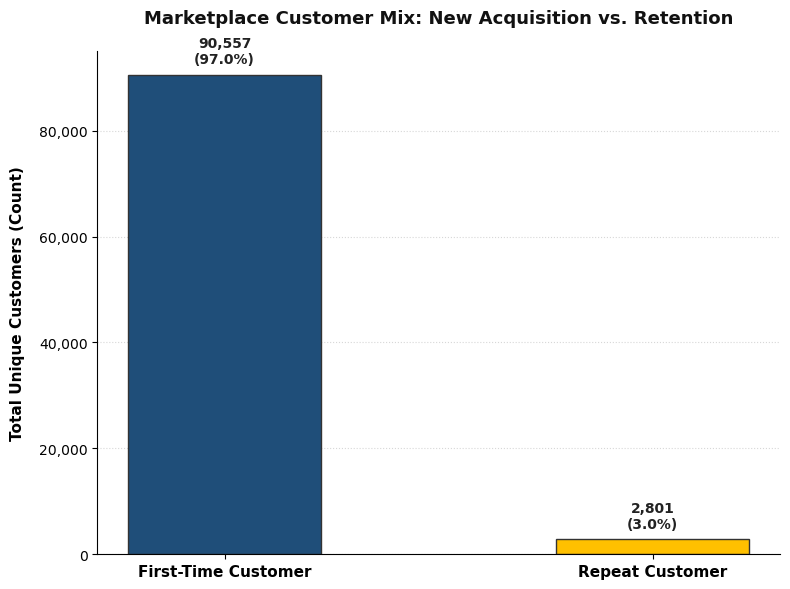

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
from google.cloud import bigquery

# 1. Initialize the BigQuery client
client = bigquery.Client()

# 2. Schema-Corrected SQL Query (o.customer_id joins to c.id)
sql_query = """
WITH customer_order_counts AS (
    -- Link using the exact keys discovered in your schema
    SELECT 
        c.customer_unique_id,
        COUNT(DISTINCT o.id) AS total_orders
    FROM `sctp-team2-project2-elt.olist_gold_mart_prod.fact_orders` AS o
    LEFT JOIN `sctp-team2-project2-elt.olist_gold_mart_prod.dim_customers` AS c
        ON o.customer_id = c.id
    WHERE o.order_status = 'delivered'
      AND c.customer_unique_id IS NOT NULL
    GROUP BY c.customer_unique_id
),
customer_segments AS (
    -- Categorize based on unique customer order history
    SELECT 
        customer_unique_id,
        CASE 
            WHEN total_orders = 1 THEN 'First-Time Customer'
            ELSE 'Repeat Customer'
        END AS customer_type
    FROM customer_order_counts
)
-- Generate final aggregated cohort counts
SELECT 
    customer_type,
    COUNT(customer_unique_id) AS total_customers
FROM customer_segments
GROUP BY customer_type;
"""

print("⏳ Querying BigQuery database (calculating unique customer counts)...")
try:
    # Execute query and stream data straight into a pandas DataFrame
    df = client.query(sql_query).to_dataframe()
    print("✅ Data successfully retrieved from BigQuery!")
except Exception as e:
    print("\n❌ Execution Failed!")
    print(f"Error Details: {e}\n")
    raise

# 3. Calculate processing metrics & sort for consistent layout execution
total_base = df['total_customers'].sum()
df['percentage'] = (df['total_customers'] / total_base) * 100
df = df.sort_values(by='total_customers', ascending=False)

# Print a preview table directly into the notebook logs
print("\n--- Summary Table Results ---")
print(df.to_string(index=False))
print("-----------------------------\n")

# 4. Initialize Matplotlib Figure Layout
fig, ax = plt.subplots(figsize=(8, 6))

# C-Suite Brand Palette (Deep Navy for Acquisition vs. Executive Amber for Retention Leverage)
colors = ['#1f4e79', '#ffc000']

bars = ax.bar(df['customer_type'], df['total_customers'], 
              color=colors[:len(df)], edgecolor='#333333', width=0.45, linewidth=1)

# 5. Chart Polish, Typography & Border Trimming
ax.set_title('Marketplace Customer Mix: New Acquisition vs. Retention', 
             fontsize=13, pad=20, fontweight='bold', color='#111111')
ax.set_ylabel('Total Unique Customers (Count)', fontsize=11, labelpad=10, fontweight='bold')

# Subtle background grid lines prioritizing readability
ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.set_axisbelow(True)

# Format y-axis values with standard thousands commas
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
ax.set_xticklabels(df['customer_type'], fontweight='bold', fontsize=11)

# Strip top and right border spines to maximize presentation whitespace
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# 6. Apply Dynamic Text Labels above Bars (Displays Count + Percentage)
for bar, pct in zip(bars, df['percentage']):
    height = bar.get_height()
    ax.annotate(f"{int(height):,}\n({pct:.1f}%)",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 6),  # 6 points vertical padding above bar
                textcoords="offset points",
                ha='center', va='bottom', 
                fontsize=10, fontweight='bold', color='#222222')

plt.tight_layout()

# 7. Render chart directly inside the notebook environment
plt.show()

Fetching complete fulfillment timeline from BigQuery...


/home/angjennfang/miniconda3/envs/pds/lib/python3.10/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


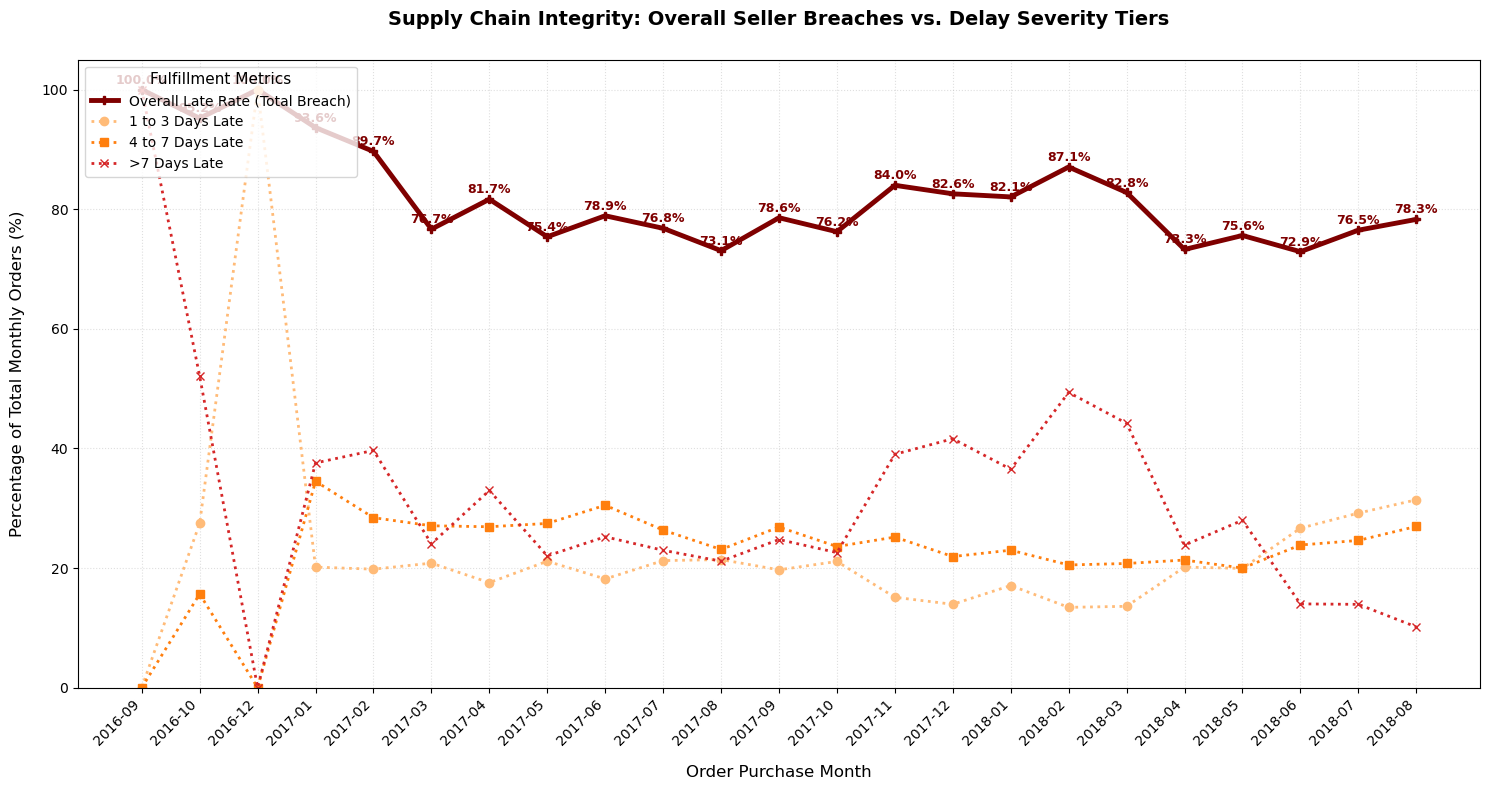

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# =====================================================================
# OVERALL VS. DETAILED LATE RANGES TIMELINE (REAL DATA ONLY)
# =====================================================================

# Query extracting total orders, overall lateness, and granular day ranges
comprehensive_late_query = """
SELECT
  DATE_TRUNC(order_purchase_timestamp, MONTH) AS order_month,
  COUNT(id) AS total_orders,
  -- Macro metric: Total orders breached
  SUM(CASE WHEN order_delivered_customer_date > shipping_limit_date THEN 1 ELSE 0 END) AS total_late_orders,
  -- Micro metrics: Granular breach ranges
  SUM(CASE WHEN DATE_DIFF(DATE(order_delivered_customer_date), DATE(shipping_limit_date), DAY) BETWEEN 1 AND 3 THEN 1 ELSE 0 END) AS late_1_3_days,
  SUM(CASE WHEN DATE_DIFF(DATE(order_delivered_customer_date), DATE(shipping_limit_date), DAY) BETWEEN 4 AND 7 THEN 1 ELSE 0 END) AS late_4_7_days,
  SUM(CASE WHEN DATE_DIFF(DATE(order_delivered_customer_date), DATE(shipping_limit_date), DAY) > 7 THEN 1 ELSE 0 END) AS late_above_7_days
FROM `olist_gold_mart_prod.fact_orders`
WHERE order_status = 'delivered'
  AND order_purchase_timestamp IS NOT NULL
  AND order_delivered_customer_date IS NOT NULL
  AND shipping_limit_date IS NOT NULL
GROUP BY order_month
ORDER BY order_month;
"""

print("Fetching complete fulfillment timeline from BigQuery...")
df_trends = client.query(comprehensive_late_query).to_dataframe()

# 1. Format dates cleanly for the X-axis timeline
df_trends['order_month'] = df_trends['order_month'].dt.strftime('%Y-%m')

# 2. Calculate percentages for the Macro line
df_trends['pct_overall_late'] = (df_trends['total_late_orders'] / df_trends['total_orders']) * 100

# 3. Calculate percentages for the Micro dotted lines
df_trends['pct_1_3_days'] = (df_trends['late_1_3_days'] / df_trends['total_orders']) * 100
df_trends['pct_4_7_days'] = (df_trends['late_4_7_days'] / df_trends['total_orders']) * 100
df_trends['pct_above_7_days'] = (df_trends['late_above_7_days'] / df_trends['total_orders']) * 100

# 4. Generate the composite visualization
plt.figure(figsize=(15, 8))

# --- MACRO TREND: Solid Crimson Line ---
plt.plot(
    df_trends['order_month'], df_trends['pct_overall_late'],
    color='#7f0000', linestyle='-', linewidth=3.5, marker='P', label='Overall Late Rate (Total Breach)'
)

# --- MICRO TRENDS: Granular Dotted Lines ---
# Range 1: 1-3 Days (Yellow Warning Dotted Line)
plt.plot(
    df_trends['order_month'], df_trends['pct_1_3_days'],
    color='#ffbb78', linestyle=':', linewidth=2.0, marker='o', label='1 to 3 Days Late'
)

# Range 2: 4-7 Days (Orange Alert Dotted Line)
plt.plot(
    df_trends['order_month'], df_trends['pct_4_7_days'],
    color='#ff7f0e', linestyle=':', linewidth=2.0, marker='s', label='4 to 7 Days Late'
)

# Range 3: >7 Days (Critical Incident Dotted Line)
plt.plot(
    df_trends['order_month'], df_trends['pct_above_7_days'],
    color='#d62728', linestyle=':', linewidth=2.0, marker='x', label='>7 Days Late'
)

# 5. Add text callouts specifically for the Overall Late Rate peaks
for idx, row in df_trends.iterrows():
    plt.text(
        idx, 
        row['pct_overall_late'] + 1.0, 
        f"{row['pct_overall_late']:.1f}%", 
        color='#7f0000', 
        ha='center', 
        fontsize=9, 
        fontweight='bold'
    )

# 6. Formatting for the presentation slide
plt.title("Supply Chain Integrity: Overall Seller Breaches vs. Delay Severity Tiers", fontsize=14, pad=25, fontweight='bold')
plt.xlabel("Order Purchase Month", fontsize=12, labelpad=12)
plt.ylabel("Percentage of Total Monthly Orders (%)", fontsize=12, labelpad=12)
plt.xticks(rotation=45, ha='right')

# Adjust limits to ensure labels don't get cut off at the top
plt.ylim(0, df_trends['pct_overall_late'].max() + 5)

plt.grid(True, linestyle=':', alpha=0.4)
plt.legend(loc='upper left', title="Fulfillment Metrics", fontsize=10, title_fontsize=11)

plt.tight_layout()
plt.show()


Fetching volume and percentage trend metrics from BigQuery...


/home/angjennfang/miniconda3/envs/pds/lib/python3.10/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


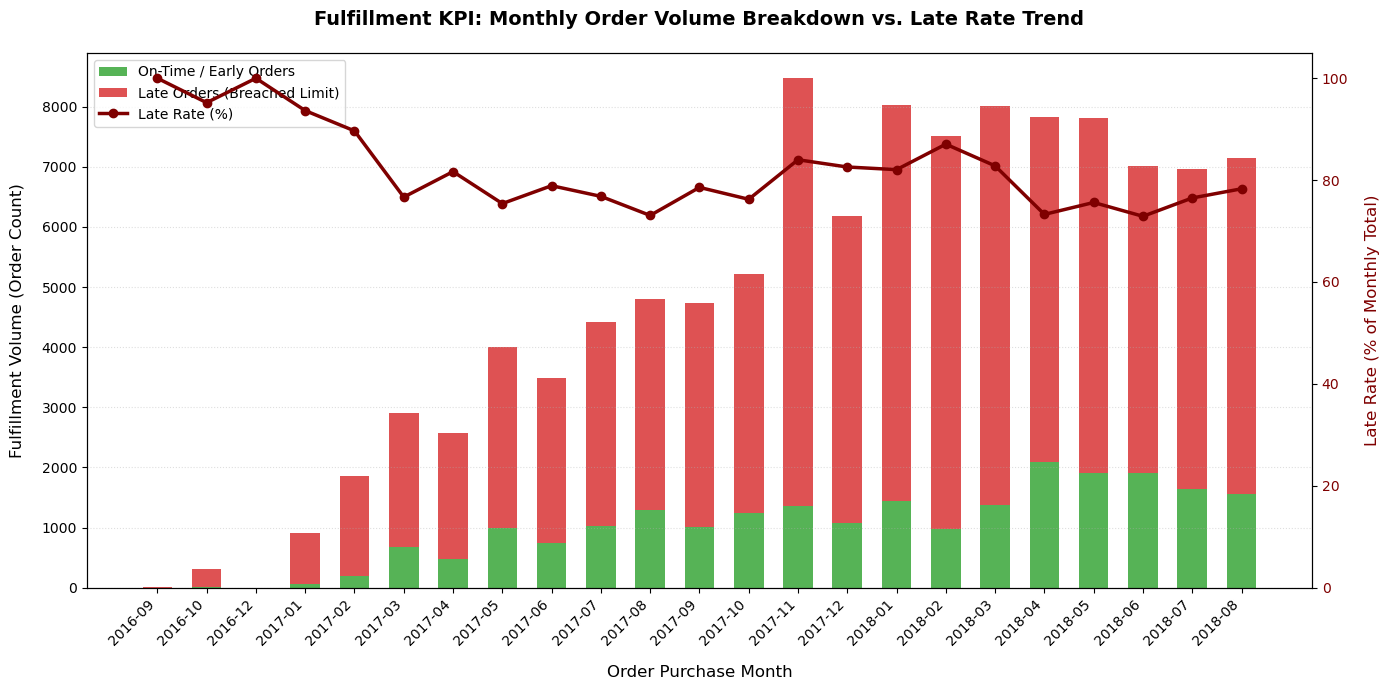

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# =====================================================================
# DUAL-AXIS FULFILLMENT TREND: VOLUMES VS. PERCENTAGE LINE
# =====================================================================

# Query extracting monthly volume comparison metrics using your shipping limit logic
dual_axis_query = """
SELECT
  DATE_TRUNC(order_purchase_timestamp, MONTH) AS order_month,
  SUM(CASE WHEN order_delivered_customer_date <= shipping_limit_date THEN 1 ELSE 0 END) AS on_time_orders,
  SUM(CASE WHEN order_delivered_customer_date > shipping_limit_date THEN 1 ELSE 0 END) AS late_orders,
  COUNT(id) AS total_orders
FROM `olist_gold_mart_prod.fact_orders`
WHERE order_status = 'delivered'
  AND order_purchase_timestamp IS NOT NULL
  AND order_delivered_customer_date IS NOT NULL
  AND shipping_limit_date IS NOT NULL
GROUP BY order_month
ORDER BY order_month;
"""

print("Fetching volume and percentage trend metrics from BigQuery...")
df = client.query(dual_axis_query).to_dataframe()

# 1. Format the date column into a clean 'YYYY-MM' string format for the x-axis
df['order_month'] = df['order_month'].dt.strftime('%Y-%m')

# 2. Calculate the Late Rate percentage for each month
df['late_rate_pct'] = (df['late_orders'] / df['total_orders']) * 100

# 3. Initialize the dual-axis plot layout (Avoiding .figure() to follow environment specs)
fig, ax1 = plt.subplots(figsize=(14, 7))
x_indices = range(len(df))

# --- PRIMARY AXIS: Stacked Bar Chart for Absolute Volumes ---
bars_ontime = ax1.bar(
    x_indices, df['on_time_orders'], 
    label='On-Time / Early Orders', color='#2ca02c', alpha=0.8, width=0.6
)
bars_late = ax1.bar(
    x_indices, df['late_orders'], bottom=df['on_time_orders'], 
    label='Late Orders (Breached Limit)', color='#d62728', alpha=0.8, width=0.6
)

# Labeling primary axis
ax1.set_xlabel('Order Purchase Month', fontsize=12, labelpad=12)
ax1.set_ylabel('Fulfillment Volume (Order Count)', fontsize=12, labelpad=12)
ax1.set_xticks(x_indices)
ax1.set_xticklabels(df['order_month'], rotation=45, ha='right')
ax1.grid(True, linestyle=':', alpha=0.4, axis='y')

# --- SECONDARY AXIS: Line Graph for Late Rate Percentage ---
ax2 = ax1.twinx()
line_pct = ax2.plot(
    x_indices, df['late_rate_pct'], 
    color='#7f0000', linestyle='-', linewidth=2.5, marker='o', label='Late Rate (%)'
)

# Labeling secondary axis
ax2.set_ylabel('Late Rate (% of Monthly Total)', fontsize=12, labelpad=12, color='#7f0000')
ax2.tick_params(axis='y', labelcolor='#7f0000')

# 4. Consolidate and build a single unified legend for the slide
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left', fontsize=10)

# 5. Visual polish and dynamic clipping protection
plt.title('Fulfillment KPI: Monthly Order Volume Breakdown vs. Late Rate Trend', fontsize=14, pad=20, fontweight='bold')
ax2.set_ylim(0, df['late_rate_pct'].max() + 5)

plt.tight_layout()
plt.show()

In [21]:
import pandas as pd

# 1. The query with the volume filter removed so every state is included
all_states_query = """
SELECT
  c.customer_state,
  COUNT(f.id) AS total_orders,
  SUM(CASE WHEN f.order_delivered_customer_date > f.shipping_limit_date THEN 1 ELSE 0 END) AS total_late_orders,
  ROUND((SUM(CASE WHEN f.order_delivered_customer_date > f.shipping_limit_date THEN 1 ELSE 0 END) / COUNT(f.id)) * 100, 2) AS late_rate_pct,
  ROUND((SUM(CASE WHEN DATE_DIFF(DATE(f.order_delivered_customer_date), DATE(f.shipping_limit_date), DAY) BETWEEN 1 AND 3 THEN 1 ELSE 0 END) / COUNT(f.id)) * 100, 2) AS pct_1_3_days_late,
  ROUND((SUM(CASE WHEN DATE_DIFF(DATE(f.order_delivered_customer_date), DATE(f.shipping_limit_date), DAY) BETWEEN 4 AND 7 THEN 1 ELSE 0 END) / COUNT(f.id)) * 100, 2) AS pct_4_7_days_late,
  ROUND((SUM(CASE WHEN DATE_DIFF(DATE(f.order_delivered_customer_date), DATE(f.shipping_limit_date), DAY) > 7 THEN 1 ELSE 0 END) / COUNT(f.id)) * 100, 2) AS pct_above_7_days_late
FROM `olist_gold_mart_prod.fact_orders` f
LEFT JOIN `olist_gold_mart_prod.dim_customers` c ON f.customer_id = c.id
WHERE f.order_status = 'delivered'
  AND c.customer_state IS NOT NULL
  AND f.order_delivered_customer_date IS NOT NULL
  AND f.shipping_limit_date IS NOT NULL
GROUP BY c.customer_state
ORDER BY late_rate_pct DESC;
"""

print("Fetching complete 27-state performance matrix...")
df_all_states = client.query(all_states_query).to_dataframe()

# 2. FORCE PANDAS TO DISPLAY ALL ROWS (This stops Jupyter/IPython from hiding data)
pd.set_option('display.max_rows', 30)

# 3. Print the entire dataframe
df_all_states

Fetching complete 27-state performance matrix...


/home/angjennfang/miniconda3/envs/pds/lib/python3.10/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,customer_state,total_orders,total_late_orders,late_rate_pct,pct_1_3_days_late,pct_4_7_days_late,pct_above_7_days_late
0,SGP,1,1,100.00,0.00,100.00,0.00
1,RR,46,46,100.00,10.87,19.57,69.57
2,AC,91,91,100.00,5.49,20.88,73.63
3,AM,163,162,99.39,6.75,11.04,79.75
4,RO,273,271,99.27,6.59,17.95,74.36
5,AP,81,80,98.77,1.23,11.11,86.42
6,SE,375,369,98.40,8.00,18.40,70.67
7,PA,1054,1037,98.39,4.27,14.42,78.84
8,AL,427,419,98.13,4.68,11.48,81.73
9,MT,1037,1017,98.07,9.74,24.11,62.97


In [28]:
!pip install geopandas shapely

Fetching performance metrics from BigQuery...


/home/angjennfang/miniconda3/envs/pds/lib/python3.10/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


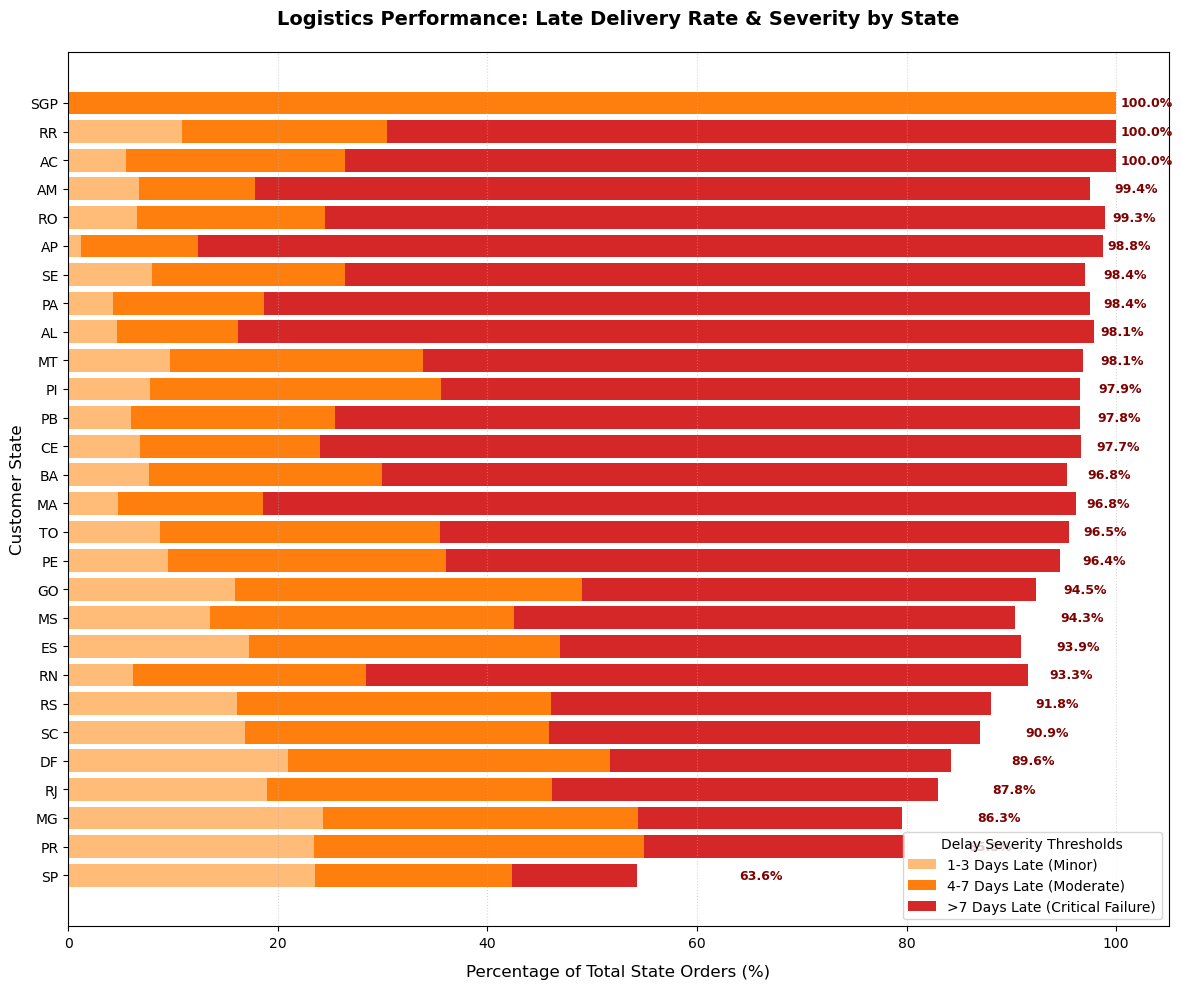

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Fetch your live 27-state performance metrics from BigQuery
state_late_query = """
SELECT
  c.customer_state,
  COUNT(f.id) AS total_orders,
  ROUND((SUM(CASE WHEN f.order_delivered_customer_date > f.shipping_limit_date THEN 1 ELSE 0 END) / COUNT(f.id)) * 100, 2) AS late_rate_pct,
  ROUND((SUM(CASE WHEN DATE_DIFF(DATE(f.order_delivered_customer_date), DATE(f.shipping_limit_date), DAY) BETWEEN 1 AND 3 THEN 1 ELSE 0 END) / COUNT(f.id)) * 100, 2) AS pct_1_3_days_late,
  ROUND((SUM(CASE WHEN DATE_DIFF(DATE(f.order_delivered_customer_date), DATE(f.shipping_limit_date), DAY) BETWEEN 4 AND 7 THEN 1 ELSE 0 END) / COUNT(f.id)) * 100, 2) AS pct_4_7_days_late,
  ROUND((SUM(CASE WHEN DATE_DIFF(DATE(f.order_delivered_customer_date), DATE(f.shipping_limit_date), DAY) > 7 THEN 1 ELSE 0 END) / COUNT(f.id)) * 100, 2) AS pct_above_7_days_late
FROM `olist_gold_mart_prod.fact_orders` f
LEFT JOIN `olist_gold_mart_prod.dim_customers` c ON f.customer_id = c.id
WHERE f.order_status = 'delivered'
  AND c.customer_state IS NOT NULL
  AND f.order_delivered_customer_date IS NOT NULL
  AND f.shipping_limit_date IS NOT NULL
GROUP BY c.customer_state
ORDER BY late_rate_pct DESC;
"""

print("Fetching performance metrics from BigQuery...")
df_state_data = client.query(state_late_query).to_dataframe()

# Sort ascending so the worst-performing states appear at the top of the horizontal chart
df_sorted = df_state_data.sort_values(by='late_rate_pct', ascending=True)

# 2. Build the Stacked Horizontal Bar Chart
fig, ax = plt.subplots(figsize=(12, 10))

# Create the segments using precise operational colors
bars_minor = ax.barh(df_sorted['customer_state'], df_sorted['pct_1_3_days_late'], 
                     color='#ffbb78', label='1-3 Days Late (Minor)')

bars_mod = ax.barh(df_sorted['customer_state'], df_sorted['pct_4_7_days_late'], 
                   left=df_sorted['pct_1_3_days_late'], 
                   color='#ff7f0e', label='4-7 Days Late (Moderate)')

bars_crit = ax.barh(df_sorted['customer_state'], df_sorted['pct_above_7_days_late'], 
                    left=df_sorted['pct_1_3_days_late'] + df_sorted['pct_4_7_days_late'], 
                    color='#d62728', label='>7 Days Late (Critical Failure)')

# Chart styling and polish
ax.set_title('Logistics Performance: Late Delivery Rate & Severity by State', fontsize=14, pad=20, fontweight='bold')
ax.set_xlabel('Percentage of Total State Orders (%)', fontsize=12, labelpad=10)
ax.set_ylabel('Customer State', fontsize=12)
ax.grid(axis='x', linestyle=':', alpha=0.5)
ax.legend(title='Delay Severity Thresholds', loc='lower right')

# Add explicit total late rate labels to the right of each bar for quick executive reading
for idx, row in df_sorted.iterrows():
    ax.text(
        row['late_rate_pct'] + 0.4, 
        df_sorted['customer_state'].tolist().index(row['customer_state']), 
        f"{row['late_rate_pct']:.1f}%", 
        va='center', fontsize=9, fontweight='bold', color='#7f0000'
    )

plt.tight_layout()
plt.show()

In [35]:
review_trends_query = """
SELECT
  DATE_TRUNC(DATE(f.order_purchase_timestamp), MONTH) AS order_month,
  COUNT(r.review_id) AS total_reviews_received,
  ROUND(AVG(r.review_score), 2) AS avg_review_score
FROM `olist_gold_mart_prod.fact_orders` f
-- Fixed: Matching the primary key 'id' from fact_orders to 'order_id' in dim_reviews
LEFT JOIN `olist_gold_mart_prod.dim_reviews` r ON f.id = r.order_id
WHERE f.order_purchase_timestamp IS NOT NULL
  AND r.review_score IS NOT NULL
GROUP BY order_month
ORDER BY order_month ASC;
"""

print("Fetching monthly review score trends with corrected keys...")
df_reviews = client.query(review_trends_query).to_dataframe()

# Display the entire historical data table
pd.set_option('display.max_rows', 35)
df_reviews

Fetching monthly review score trends with corrected keys...


/home/angjennfang/miniconda3/envs/pds/lib/python3.10/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,order_month,total_reviews_received,avg_review_score
0,2016-09-01,7,1.00
1,2016-10-01,372,3.49
2,2016-12-01,1,5.00
3,2017-01-01,938,4.04
4,2017-02-01,1980,4.00
5,2017-03-01,3006,4.04
6,2017-04-01,2665,4.00
7,2017-05-01,4125,4.12
8,2017-06-01,3564,4.12
9,2017-07-01,4516,4.11


/home/angjennfang/miniconda3/envs/pds/lib/python3.10/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
/tmp/ipykernel_1574/1215737718.py:36: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(df_reviews['order_month'], rotation=45, ha='right')


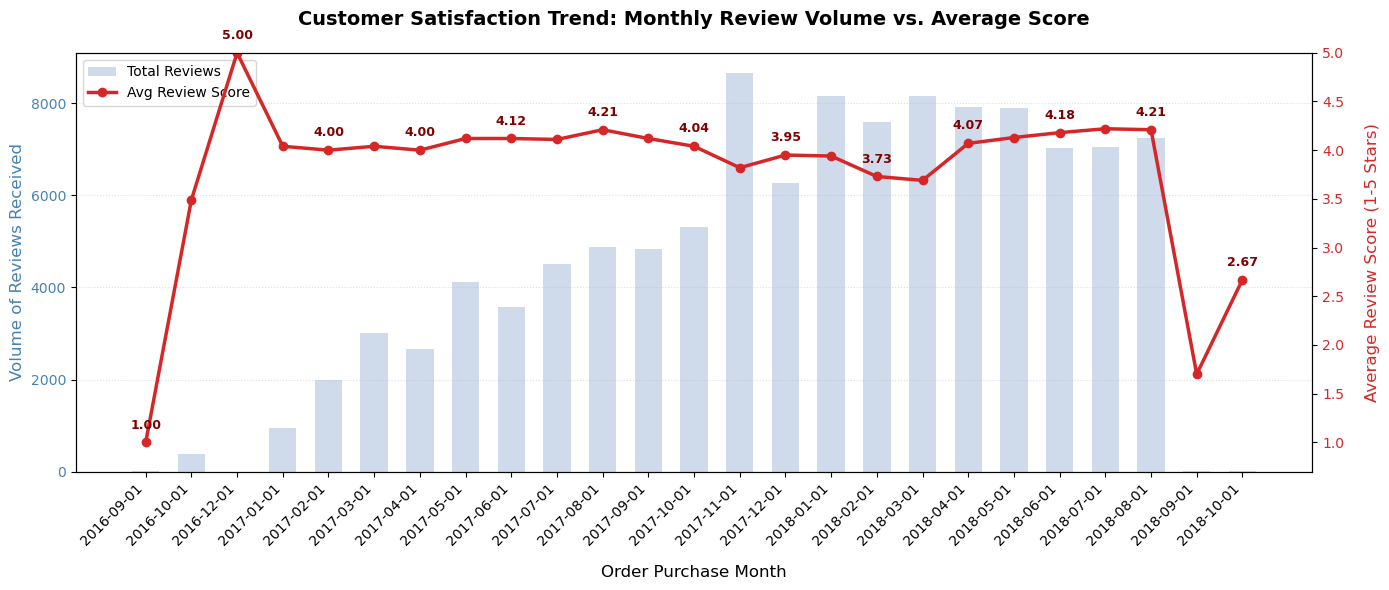

In [36]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Fetch the data using the corrected query
review_trends_query = """
SELECT
  DATE_TRUNC(DATE(f.order_purchase_timestamp), MONTH) AS order_month,
  COUNT(r.review_id) AS total_reviews_received,
  ROUND(AVG(r.review_score), 2) AS avg_review_score
FROM `olist_gold_mart_prod.fact_orders` f
LEFT JOIN `olist_gold_mart_prod.dim_reviews` r ON f.id = r.order_id
WHERE f.order_purchase_timestamp IS NOT NULL
  AND r.review_score IS NOT NULL
GROUP BY order_month
ORDER BY order_month ASC;
"""

print("Downloading monthly metrics...")
df_reviews = client.query(review_trends_query).to_dataframe()

# Ensure the month column is formatted as a string for clean X-axis spacing
df_reviews['order_month'] = df_reviews['order_month'].astype(str)

# 2. Initialize the dual-axis chart layout
fig, ax1 = plt.subplots(figsize=(14, 6))

# --- LEFT AXIS: Volume of Reviews (Subtle Blue Bars) ---
color_bars = '#b0c4de' # Professional steel blue
ax1.bar(df_reviews['order_month'], df_reviews['total_reviews_received'], 
        color=color_bars, alpha=0.6, width=0.6, label='Total Reviews')
ax1.set_xlabel('Order Purchase Month', fontsize=12, labelpad=12)
ax1.set_ylabel('Volume of Reviews Received', color='#4682b4', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#4682b4')

# Rotate labels slightly so dates don't overlap or truncate
ax1.set_xticklabels(df_reviews['order_month'], rotation=45, ha='right')
ax1.grid(axis='y', linestyle=':', alpha=0.4)

# --- RIGHT AXIS: Average Review Score (Crimson Line) ---
ax2 = ax1.twinx() # Creates the shared X-axis for the line chart
color_line = '#d62728' # High-contrast crimson
ax2.plot(df_reviews['order_month'], df_reviews['avg_review_score'], 
         color=color_line, marker='o', linewidth=2.5, label='Avg Review Score')
ax2.set_ylabel('Average Review Score (1-5 Stars)', color=color_line, fontsize=12, labelpad=15)
ax2.tick_params(axis='y', labelcolor=color_line)

# Dynamically pad the line view limits so score fluctuations are clearly visible
ax2.set_ylim(df_reviews['avg_review_score'].min() - 0.3, 5.0)

# Add data value markers directly onto the key turning points of the line
for idx, row in df_reviews.iterrows():
    # Only label every other month or specific peaks/valleys to keep it clean
    if idx % 2 == 0: 
        ax2.annotate(f"{row['avg_review_score']:.2f}", 
                     (row['order_month'], row['avg_review_score']),
                     textcoords="offset points", xytext=(0,10), 
                     ha='center', fontsize=9, fontweight='bold', color='#7f0000')

# 3. Titles and Legends
plt.title('Customer Satisfaction Trend: Monthly Review Volume vs. Average Score', fontsize=14, pad=20, fontweight='bold')

# Combine legends from both axes into one clean box
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

/home/angjennfang/miniconda3/envs/pds/lib/python3.10/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Chart successfully generated and saved to your workspace as 'operational_3_pillars_chart.png'!


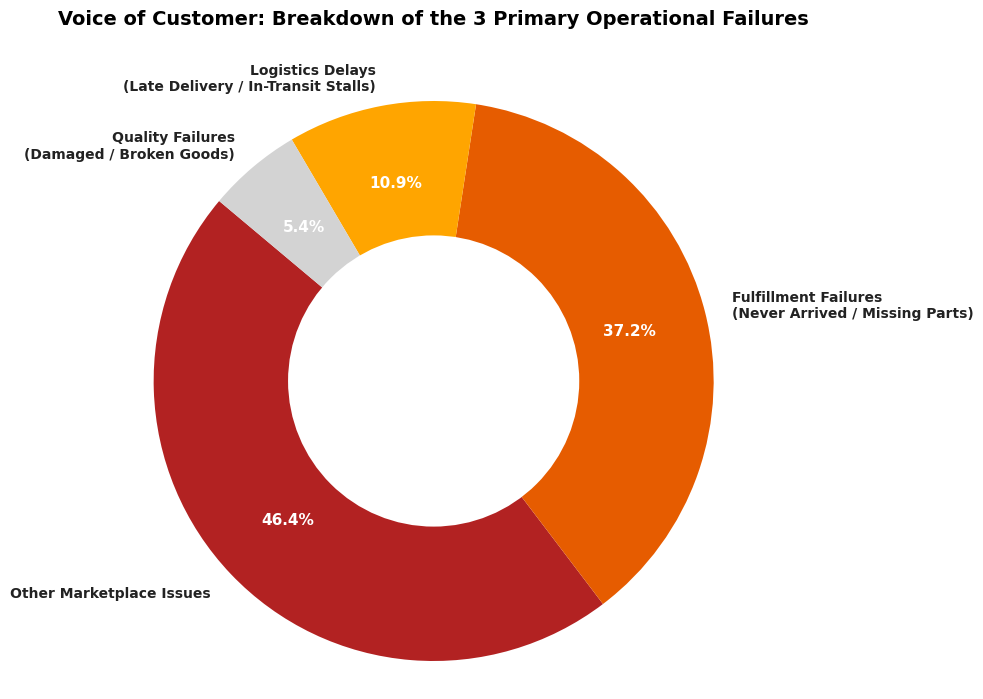

In [41]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Fetch data consolidated into your exact 3 operational pillars
pillar_feedback_query = """
SELECT
  CASE 
    -- Pillar 1: Fulfillment Failures (Never Arrived / Missing parts / Incomplete)
    WHEN REGEXP_CONTAINS(LOWER(r.review_comment_message), 'não receb|recebi|não entreg|entregou|faltand|veio faltand|sumiu') 
         THEN 'Fulfillment Failures\\n(Never Arrived / Missing Parts)'
    
    -- Pillar 2: Logistics Delays (Late Delivery / In-transit stalls / Missed SLAs)
    WHEN REGEXP_CONTAINS(LOWER(r.review_comment_message), 'atras|demor|prazo|chegou depois|lentid|aguardand') 
         THEN 'Logistics Delays\\n(Late Delivery / In-Transit Stalls)'
    
    -- Pillar 3: Quality Failures (Damaged / Broken goods / Wrong items)
    WHEN REGEXP_CONTAINS(LOWER(r.review_comment_message), 'defeit|quebrad|estrag|errado|falso|ruim|riscado|danificad') 
         THEN 'Quality Failures\\n(Damaged / Broken Goods)'
    
    ELSE 'Other Marketplace Issues'
  END AS operational_pillar,
  COUNT(r.review_id) AS total_reviews
FROM `olist_gold_mart_prod.fact_orders` f
LEFT JOIN `olist_gold_mart_prod.dim_reviews` r ON f.id = r.order_id
WHERE r.review_score <= 2
  AND r.review_comment_message IS NOT NULL
GROUP BY operational_pillar
ORDER BY total_reviews DESC;
"""

print("Downloading and sorting metrics into your 3 core pillars...")
df_pillars = client.query(pillar_feedback_query).to_dataframe()

# 2. Configure executive presentation colors for the slices
# Dark Red for Fulfillment, Orange-Red for Logistics, Amber for Quality, Light Grey for Misc.
pillar_colors = ['#b22222', '#e65c00', '#ffa500', '#d3d3d3'] 

# 3. Create the Donut Chart layout
fig, ax = plt.subplots(figsize=(10, 8))

wedges, texts, autotexts = ax.pie(
    df_pillars['total_reviews'], 
    labels=df_pillars['operational_pillar'],
    autopct='%1.1f%%', 
    startangle=140, 
    colors=pillar_colors,
    textprops=dict(color="#222222", fontsize=11, fontweight='bold'),
    pctdistance=0.72
)

# Draw a clean white cutout circle in the center to complete the donut visual
centre_circle = plt.Circle((0,0), 0.52, fc='white')
fig.gca().add_artist(centre_circle)

# Formatting text properties inside and outside the chart wedges to prevent overlaps
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)

for text in texts:
    text.set_fontsize(10)

ax.axis('equal')  
plt.title('Voice of Customer: Breakdown of the 3 Primary Operational Failures', 
          fontsize=14, pad=35, fontweight='bold')

# Save the plot directly as an image file for easy extraction into your slide deck
plt.savefig('operational_3_pillars_chart.png', dpi=300, bbox_inches='tight')
print("Chart successfully generated and saved to your workspace as 'operational_3_pillars_chart.png'!")

In [47]:
import csv
import pandas as pd
from google.cloud import bigquery

# 1. Initialize the BigQuery client pointing directly to your active project team space
target_project = "sctp-team2-project2-elt"
print(f"Initializing BigQuery client for project space: {target_project}...")
client = bigquery.Client(project=target_project)

# 2. SQL Query referencing the accurate absolute workspace paths
half_yearly_table_query = """
SELECT
  CONCAT(
    CAST(EXTRACT(YEAR FROM f.order_purchase_timestamp) AS STRING), ' ',
    CASE WHEN EXTRACT(MONTH FROM f.order_purchase_timestamp) <= 6 THEN 'H1' ELSE 'H2' END
  ) AS half_year,
  COUNT(DISTINCT f.id) AS total_negative_orders,
  
  -- Pillar 1: Fulfillment Failures
  SUM(CASE WHEN REGEXP_CONTAINS(LOWER(r.review_comment_message), 'não receb|recebi|não entreg|entregou|faltand|veio faltand|sumiu') THEN 1 ELSE 0 END) AS fulfillment_failures,
  
  -- Pillar 2: Logistics Delays
  SUM(CASE WHEN REGEXP_CONTAINS(LOWER(r.review_comment_message), 'atras|demor|prazo|chegou depois|lentid|aguardand') THEN 1 ELSE 0 END) AS logistics_delays,
  
  -- Pillar 3: Quality Failures
  SUM(CASE WHEN REGEXP_CONTAINS(LOWER(r.review_comment_message), 'defeit|quebrad|estrag|errado|falso|ruim|riscado|danificad') THEN 1 ELSE 0 END) AS quality_failures,
  
  -- Pillar 4: Marketplace & Service Issues
  SUM(CASE WHEN NOT REGEXP_CONTAINS(LOWER(r.review_comment_message), 'não receb|recebi|não entreg|entregou|faltand|veio faltand|sumiu|atras|demor|prazo|chegou depois|lentid|aguardand|defeit|quebrad|estrag|errado|falso|ruim|riscado|danificad') THEN 1 ELSE 0 END) AS marketplace_service_issues

FROM `sctp-team2-project2-elt.olist_gold_mart_prod.fact_orders` f
LEFT JOIN `sctp-team2-project2-elt.olist_gold_mart_prod.dim_reviews` r ON f.id = r.order_id
WHERE r.review_score <= 2
  AND r.review_comment_message IS NOT NULL
GROUP BY half_year
ORDER BY half_year ASC;
"""

print("1. Running BigQuery data aggregation across team pillars...")
df_matrix = client.query(half_yearly_table_query).to_dataframe()

# 3. Crash-Safe CSV File Outflow
print("2. Writing presentation matrix to local disk safely...")
csv_filename = "half_yearly_operational_problems.csv"

with open(csv_filename, mode="w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(df_matrix.columns)
    writer.writerows(df_matrix.values)
print(f"   Saved to workspace as '{csv_filename}'!")

# 4. Format Column Metadata for clean notebook presentation views
df_presentation = df_matrix.rename(columns={
    'half_year': 'Half-Year Period',
    'total_negative_orders': 'Total Negative Orders (≤2 Stars)',
    'fulfillment_failures': 'Fulfillment Failures',
    'logistics_delays': 'Logistics Delays',
    'quality_failures': 'Quality Failures',
    'marketplace_service_issues': 'Marketplace & Service Issues'
})

print("\n3. Current Output Summary:")
df_presentation

Initializing BigQuery client for project space: sctp-team2-project2-elt...
1. Running BigQuery data aggregation across team pillars...


/home/angjennfang/miniconda3/envs/pds/lib/python3.10/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


2. Writing presentation matrix to local disk safely...
   Saved to workspace as 'half_yearly_operational_problems.csv'!

3. Current Output Summary:


,Half-Year Period,Total Negative Orders (≤2 Stars),Fulfillment Failures,Logistics Delays,Quality Failures,Marketplace & Service Issues
0,2016 H2,89,35,28,5,53
1,2017 H1,1473,617,323,159,826
2,2017 H2,3258,1614,640,308,2070
3,2018 H1,4867,2531,1093,515,2955
4,2018 H2,1061,476,185,122,672


Chart successfully bypassed pandas and saved to workspace as 'half_yearly_4_pillars_distribution.png'!


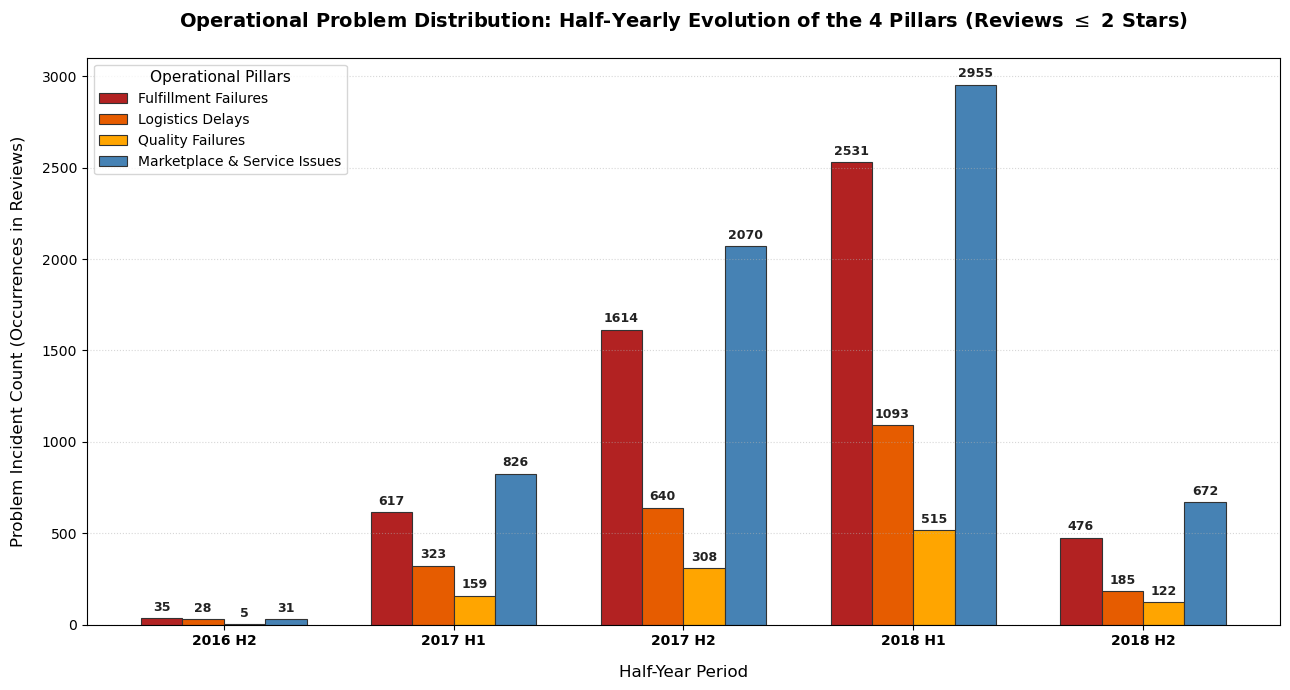

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Recreate the dataset
data = {
    'Half-Year Period': ['2016 H2', '2017 H1', '2017 H2', '2018 H1', '2018 H2'],
    'Fulfillment Failures': [35, 617, 1614, 2531, 476],
    'Logistics Delays': [28, 323, 640, 1093, 185],
    'Quality Failures': [5, 159, 308, 515, 122],
    'Marketplace & Service Issues': [31, 826, 2070, 2955, 672]
}

categories = list(data.keys())[1:]  # The 4 pillars
periods = data['Half-Year Period']  # X-axis ticks

# 2. Set up native Matplotlib matrix calculations for grouped bars
x = np.arange(len(periods))  # Label locations: [0, 1, 2, 3, 4]
width = 0.18  # Width of each individual bar

fig, ax = plt.subplots(figsize=(13, 7))

# Explicit presentation colors
colors = ['#b22222', '#e65c00', '#ffa500', '#4682b4']

# Manually compute bar offsets to completely bypass df.plot()
for i, category in enumerate(categories):
    # Offset each category group slightly to sit side-by-side
    bar_positions = x + (i - 1.5) * width
    rects = ax.bar(bar_positions, data[category], width, label=category, 
                   color=colors[i], edgecolor='#333333', linewidth=0.8)
    
    # Add numeric value labels on top of every bar
    for rect in rects:
        height = rect.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', 
                        fontsize=9, fontweight='bold', color='#222222')

# 3. Chart styling and layout polish
ax.set_title('Operational Problem Distribution: Half-Yearly Evolution of the 4 Pillars (Reviews $\leq$ 2 Stars)', 
             fontsize=14, pad=22, fontweight='bold')
ax.set_xlabel('Half-Year Period', fontsize=12, labelpad=12)
ax.set_ylabel('Problem Incident Count (Occurrences in Reviews)', fontsize=12, labelpad=12)
ax.set_xticks(x)
ax.set_xticklabels(periods, fontweight='bold', fontsize=10)
ax.grid(axis='y', linestyle=':', alpha=0.5)

# Legend positioning
ax.legend(title='Operational Pillars', fontsize=10, title_fontsize=11, loc='upper left')

plt.tight_layout()

# 4. Save the visualization directly to disk
output_filename = 'half_yearly_4_pillars_distribution.png'
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
print(f"Chart successfully bypassed pandas and saved to workspace as '{output_filename}'!")

| Operational Pillar | Primary Customer Symptoms | Internal Department Owner | Strategic Action Required |
| :--- | :--- | :--- | :--- |
| **1. Fulfillment Failures** | • "Item never arrived"<br>• "Package was empty"<br>• "Missing half the parts" | Warehouse & Supply Chain Ops | Audit packing line cameras, implement weight-check verification before shipping, and optimize inventory counts. |
| **2. Logistics Delays** | • "Arrived 2 weeks late"<br>• "Stuck in transit"<br>• "Missed delivery promise" | Last-Mile & Carrier Relations | Re-negotiate carrier SLA penalties, diversify regional courier networks, and adjust dynamic delivery promises on the app. |
| **3. Quality Failures** | • "Arrived shattered/broken"<br>• "Item is defective/falso"<br>• "Sent the wrong size" | Merchant Quality & Compliance | Enforce stricter merchant packaging guidelines, implement a "3-strike" policy for low-rated sellers, and ease the return process. |
| **4. Marketplace & Platform Issues** | • "App crashed during checkout"<br>• "Seller won't reply to my chats"<br>• "Charged twice / refund stuck" | Product Team & Customer Support | Optimize app checkout infrastructure, mandate maximum merchant response times, and automate immediate refund protocols for canceled orders. |

In [56]:
import csv
import pandas as pd
from google.cloud import bigquery

# 1. Initialize the BigQuery client pointing directly to your project space
target_project = "sctp-team2-project2-elt"
print(f"Initializing BigQuery client for project space: {target_project}...")
client = bigquery.Client(project=target_project)

# 2. SQL Query designed specifically for your flattened schema matrix
revenue_table_query = """
SELECT
  p.product_category AS product_category,
  ROUND(SUM(o.price), 2) AS total_revenue,
  COUNT(DISTINCT o.id) AS total_orders,
  ROUND(SUM(o.price) / COUNT(DISTINCT o.id), 2) AS avg_order_value
FROM `sctp-team2-project2-elt.olist_gold_mart_prod.fact_orders` o
JOIN `sctp-team2-project2-elt.olist_gold_mart_prod.dim_products` p 
  ON o.product_id = p.product_id
WHERE p.is_current = TRUE  -- Filters out historical dimension duplicates
  AND p.product_category IS NOT NULL
GROUP BY product_category
ORDER BY total_revenue DESC;
"""

print("1. Running BigQuery financial aggregation...")
df_revenue = client.query(revenue_table_query).to_dataframe()

# 3. Crash-Safe CSV File Outflow (Bypassing the broken pandas 'SequenceNotStr' bug)
print("2. Writing revenue matrix to local disk safely...")
csv_filename = "revenue_vs_product_category.csv"

with open(csv_filename, mode="w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(df_revenue.columns)
    writer.writerows(df_revenue.values)
print(f"   Saved to workspace as '{csv_filename}'!")

# 4. Format Column Metadata for clean notebook presentation views
df_presentation = df_revenue.rename(columns={
    'product_category': 'Product Category',
    'total_revenue': 'Total Revenue ($)',
    'total_orders': 'Total Orders Count',
    'avg_order_value': 'Avg Order Value ($)'
})

print("\n3. Visualizing Revenue Table Summary:")
df_presentation

Initializing BigQuery client for project space: sctp-team2-project2-elt...
1. Running BigQuery financial aggregation...


/home/angjennfang/miniconda3/envs/pds/lib/python3.10/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


2. Writing revenue matrix to local disk safely...
   Saved to workspace as 'revenue_vs_product_category.csv'!

3. Visualizing Revenue Table Summary:


,Product Category,Total Revenue ($),Total Orders Count,Avg Order Value ($)
0,health_beauty,1258681.34,8836,142.45
1,watches_gifts,1205005.68,5624,214.26
2,bed_bath_table,1036988.68,9417,110.12
3,sports_leisure,988048.97,7720,127.99
4,computers_accessories,911954.32,6689,136.34
...,...,...,...,...
66,flowers,1110.04,29,38.28
67,home_comfort_2,760.27,24,31.68
68,cds_dvds_musicals,730.00,12,60.83
69,fashion_childrens_clothes,569.85,8,71.23


🎉 Pie chart successfully generated and saved to your workspace as 'top_10_revenue_pie_chart.png'!


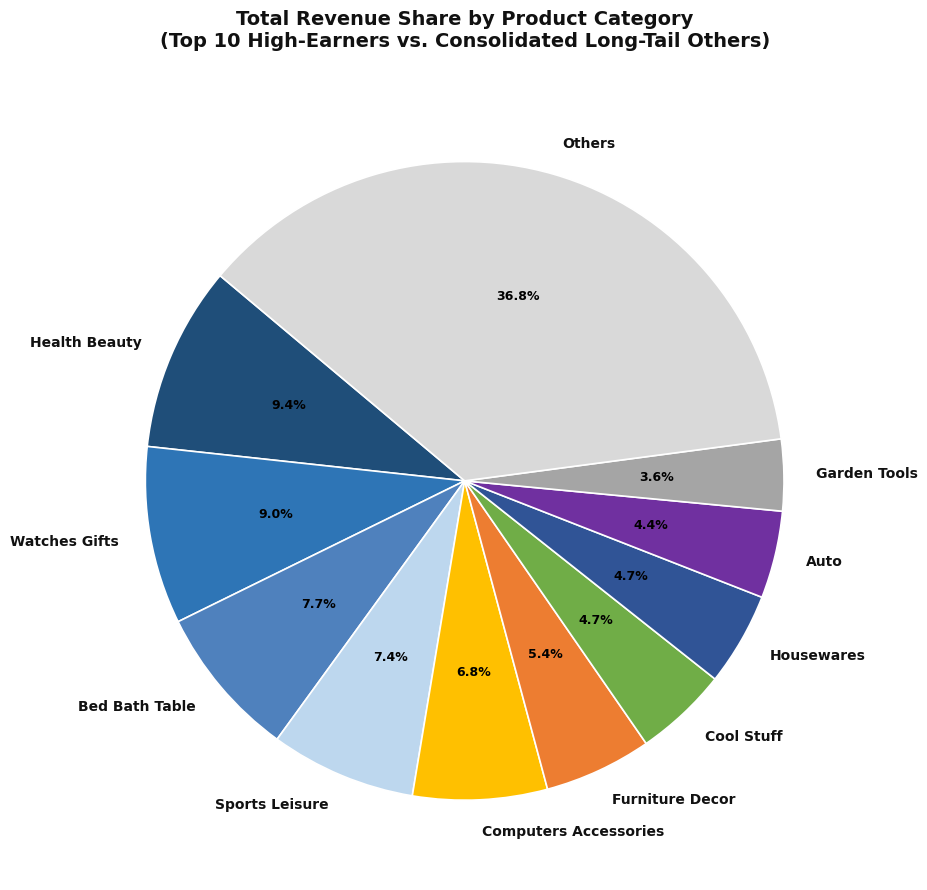

In [62]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load the generated revenue data
csv_filename = "revenue_vs_product_category.csv"
try:
    df = pd.read_csv(csv_filename)
except FileNotFoundError:
    print(f"❌ '{csv_filename}' not found. Please run the revenue database query script first!")
    raise

# 2. Process data: Isolate Top 10 and consolidate the rest into "Others"
top_n = 10
df_top = df.head(top_n).copy()
df_others = df.iloc[top_n:]

# Calculate aggregate financial values for the remaining long-tail categories
others_revenue = df_others['total_revenue'].sum()

# Build the consolidated visual dataset
pie_data = pd.concat([
    df_top, 
    pd.DataFrame({'product_category': ['Others'], 'total_revenue': [others_revenue]})
], ignore_index=True)

# Format category strings to look clean and professional (remove underscores, capitalize)
labels = [str(cat).replace('_', ' ').title() for cat in pie_data['product_category']]
sizes = pie_data['total_revenue']

# 3. Build the chart layout using pure Matplotlib (Bypassing broken pandas plot)
# Slightly larger figure size (11x9) to give the 11 segments and labels ample breathing room
fig, ax = plt.subplots(figsize=(11, 9))

# Professional expanded executive color palette (Blues, accents, greens, and a neutral gray for Others)
colors = [
    '#1f4e79', '#2e75b6', '#4f81bd', '#bdd7ee', '#ffc000', 
    '#ed7d31', '#70ad47', '#305496', '#7030a0', '#a5a5a5', 
    '#d9d9d9'  # Clean light gray designated explicitly for the 'Others' slice
]

wedges, texts, autotexts = ax.pie(
    sizes, 
    labels=labels, 
    autopct='%1.1f%%',       # Display percentage share on slices
    startangle=140,          # Rotate angle for optimal layout balance
    colors=colors[:len(sizes)],
    wedgeprops=dict(edgecolor='#ffffff', linewidth=1.2, antialiased=True) # Crisp white borders
)

# 4. Polish and Chart Typography
plt.setp(autotexts, size=9, weight="bold", color="black")   # Styling percentage numbers inside slices
plt.setp(texts, size=10, weight="bold", color="#111111")     # Styling category text labels outside slices

ax.set_title('Total Revenue Share by Product Category\n(Top 10 High-Earners vs. Consolidated Long-Tail Others)', 
             fontsize=14, pad=25, fontweight='bold', color='#111111')

plt.tight_layout()

# 5. Save directly to your active workspace
output_image = "top_10_revenue_pie_chart.png"
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"🎉 Pie chart successfully generated and saved to your workspace as '{output_image}'!")

/tmp/ipykernel_1574/86432647.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(df_top['product_category'], fontweight='bold', fontsize=10)


🎉 Chart successfully generated and saved to your workspace as 'top_10_product_categories_revenue.png'!


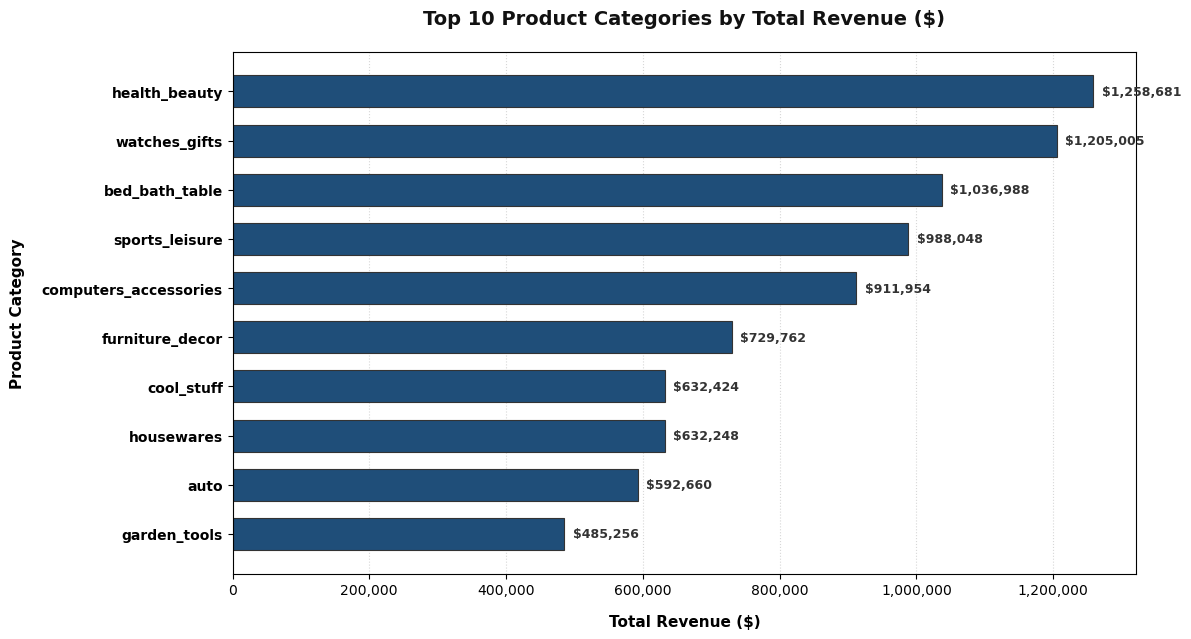

In [58]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load the generated revenue data
csv_filename = "revenue_vs_product_category.csv"
try:
    df = pd.read_csv(csv_filename)
except FileNotFoundError:
    print(f"❌ '{csv_filename}' not found. Please run the revenue database query script first!")
    raise

# 2. Select the Top 10 categories for visual clarity and clean presentation
top_n = 10
df_top = df.head(top_n).copy()

# Sort ascending so that the highest revenue bar appears at the top of a horizontal chart
df_top = df_top.sort_values(by='total_revenue', ascending=True)

# 3. Create the chart layout using pure Matplotlib (Bypassing broken pandas plot)
# Slightly reduced height (6.5) to keep the 10 bars looking proportional and sharp
fig, ax = plt.subplots(figsize=(12, 6.5))

# Executive-style deep ocean blue color profile
bar_color = '#1f4e79'

bars = ax.barh(df_top['product_category'], df_top['total_revenue'], 
               color=bar_color, edgecolor='#333333', height=0.65, linewidth=0.8)

# 4. Polish and Chart Typography
ax.set_title(f'Top {top_n} Product Categories by Total Revenue ($)', 
             fontsize=14, pad=20, fontweight='bold', color='#111111')
ax.set_xlabel('Total Revenue ($)', fontsize=11, labelpad=12, fontweight='bold')
ax.set_ylabel('Product Category', fontsize=11, labelpad=12, fontweight='bold')

# Clean up grid lines (vertical lines only for a horizontal chart)
ax.grid(axis='x', linestyle=':', alpha=0.5)
ax.set_axisbelow(True)

# Format the X-axis numbers with thousand-separator commas
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Make category text bold and clear
ax.set_yticklabels(df_top['product_category'], fontweight='bold', fontsize=10)

# 5. Add dynamic numeric data labels to the right of each horizontal bar
for bar in bars:
    width = bar.get_width()
    if width > 0:
        # Format label as standard currency with a thousands separator
        label_text = f"${width:,.2f}" if width < 100000 else f"${int(width):,}"
        
        ax.annotate(label_text,
                    xy=(width, bar.get_y() + bar.get_height() / 2),
                    xytext=(6, 0),  # 6 points horizontal offset to move text outside the bar
                    textcoords="offset points",
                    ha='left', va='center', 
                    fontsize=9, fontweight='bold', color='#333333')

# Maximize padding safety margins to guarantee no text clipping occurs
plt.tight_layout()

# 6. Save directly to your active workspace
output_image = "top_10_product_categories_revenue.png"
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"🎉 Chart successfully generated and saved to your workspace as '{output_image}'!")

In [55]:
from google.cloud import bigquery

client = bigquery.Client(project="sctp-team2-project2-elt")
dataset_id = "sctp-team2-project2-elt.olist_gold_mart_prod"

for table_name in ["fact_orders", "dim_products"]:
    table_ref = client.get_table(f"{dataset_id}.{table_name}")
    print(f"\n📋 Columns inside '{table_name}':")
    print("-" * 40)
    for field in table_ref.schema:
        print(f"• {field.name} ({field.field_type})")


📋 Columns inside 'fact_orders':
----------------------------------------
• id (STRING)
• customer_id (STRING)
• order_status (STRING)
• order_purchase_timestamp (TIMESTAMP)
• order_approved_at (TIMESTAMP)
• order_delivered_carrier_date (TIMESTAMP)
• order_delivered_customer_date (TIMESTAMP)
• order_estimated_delivery_date (TIMESTAMP)
• order_item_id (INTEGER)
• product_id (STRING)
• seller_id (STRING)
• shipping_limit_date (TIMESTAMP)
• price (FLOAT)
• freight_value (FLOAT)
• payment_sequential (INTEGER)
• payment_type (STRING)
• payment_installments (INTEGER)
• payment_value (FLOAT)
• has_invalid_delivery_date (BOOLEAN)
• is_overdue_delivery (BOOLEAN)
• is_high_value_product (BOOLEAN)
• has_missing_delivery_date (BOOLEAN)
• is_long_delivery (BOOLEAN)
• has_missing_payment_info (BOOLEAN)
• has_no_items (BOOLEAN)

📋 Columns inside 'dim_products':
----------------------------------------
• surrogate_key (STRING)
• product_id (STRING)
• product_category (STRING)
• product_name_lenght (FL